<a href="https://colab.research.google.com/github/noahmartel2007/les-filtres-/blob/main/filtre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Définir une fonction passe_bas(ω, ω₀) qui renvoie la fonction de transfert d'un passe-bas d'ordre 1 de pulsation de coupure ω₀.

Tracer son diagramme de Bode sur 2 décades avant et après $ω₀$ dans le cas où $f_0=\dfrac{ω₀}{2\pi}=\dfrac{1}{2\pi}$ kHz.

On indique qu'en Python:

- le nombre complexe mathématique $i$ tel que $i^2=-1$ s'écrit 1j et si l'on souhaite écrire $2i$, il faut noter 2j
- la commande abs(x) renvoie le module du nombre complexe x
- cmath.phase(x) renvoie son argument (après avoir chargé la bibliothèque cmath)
- la commande plt.semilogx() permet de tracer une fonction avec une abscisse logarithmique
- np.log(x) calcule le logarithme népérien (ou naturel), noté $\ln(x)$. Sa base est le nombre d'Euler, $e \approx 2.718$
- np.log10(x) calcule le logarithme en base 10, noté $\log_{10}(x)$.

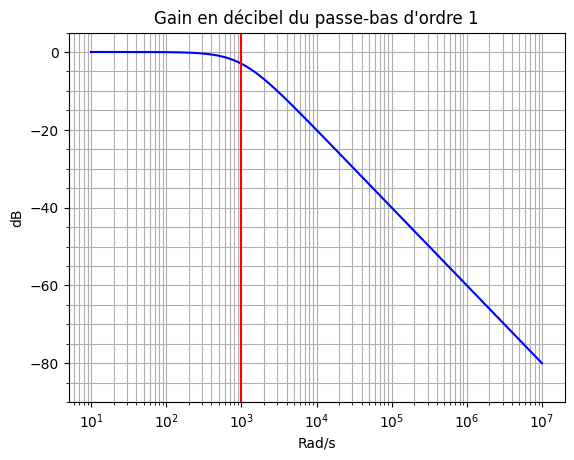

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def passe_bas(ω, ω0):
  return 1 / (1 + ω/ω0 * 1j)

R = 1e3
C = 1e-6
ω0 = 1 / (R * C)

liste_ω = np.logspace(np.log10(ω0 / 100), np.log10(10000 * ω0), 1000)

Gain_dB_pb = []
for ω in liste_ω:
    G = 20 * np.log10(abs(passe_bas(ω, ω0)))
    Gain_dB_pb.append(G)

plt.subplot()
plt.title("Gain en décibel du passe-bas d'ordre 1")
plt.semilogx(liste_ω, Gain_dB_pb, color='b')
plt.xlabel("Rad/s")
plt.ylabel("dB")
plt.grid(which = 'both')
plt.minorticks_on()
plt.axvline(x = ω0, color = 'r', linestyle = '-')
plt.ylim(-90, 5)
plt.show()



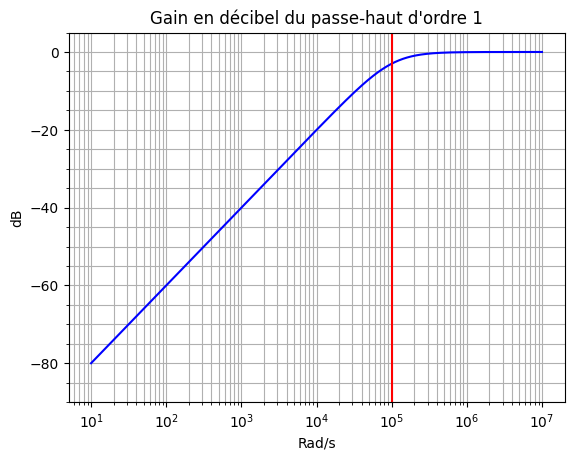

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def passe_haut(ω, ω0):
  return (ω/ω0 * 1j) / (1 + ω/ω0 * 1j)

R = 1e3
C = 1e-8
ω0 = 1 / (R * C)

liste_ω = np.logspace(np.log10(ω0 / 10000), np.log10(100 * ω0), 1000)

Gain_dB_ph = []
for ω in liste_ω:
    G = 20 * np.log10(abs(passe_haut(ω, ω0)))
    Gain_dB_ph.append(G)

plt.subplot()
plt.title("Gain en décibel du passe-haut d'ordre 1")
plt.semilogx(liste_ω, Gain_dB_ph, color='b')
plt.xlabel("Rad/s")
plt.ylabel("dB")
plt.grid(which = 'both')
plt.minorticks_on()
plt.axvline(x = ω0, color = 'r', linestyle = '-')
plt.ylim(-90, 5)
plt.show()

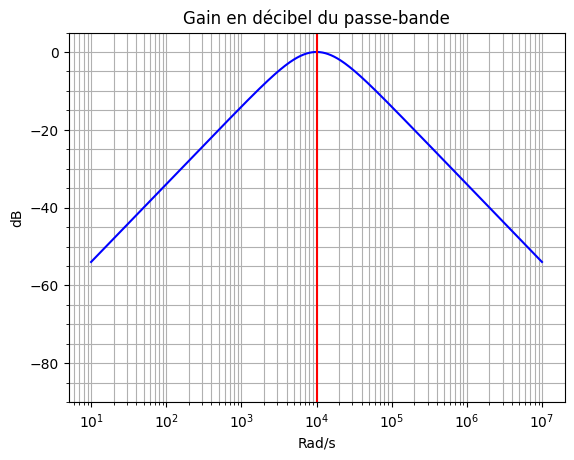

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def passe_bande(ω, ω0, Q):
  return 1 / (1 + Q * (ω/ω0 - ω0/ω) * 1j)

ω0 = 10000
Q = 0.5
liste_ω = np.logspace(1, 7, 1000)

Gain_dB_pbande = []
for ω in liste_ω:
    G = 20 * np.log10(abs(passe_bande(ω, ω0, Q)))
    Gain_dB_pbande.append(G)

plt.subplot()
plt.title("Gain en décibel du passe-bande")
plt.semilogx(liste_ω, Gain_dB_pbande, color='b')
plt.xlabel("Rad/s")
plt.ylabel("dB")
plt.grid(which = 'both')
plt.minorticks_on()
plt.axvline(x = ω0, color = 'r', linestyle = '-')
plt.ylim(-90, 5)
plt.show()

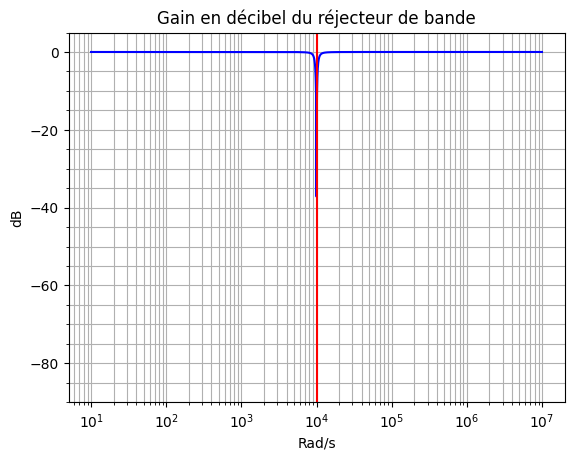

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def rejecteur_bande(ω, ω0, Q):
    X = Q * (ω/ω0 - ω0/ω)

    return (1j * X) / (1 + 1j * X)

ω0 = 10000
Q = 10
liste_ω = np.logspace(1, 7, 10000)

Gain_dB_pbande = []
for ω in liste_ω:
    G = 20 * np.log10(abs(rejecteur_bande(ω, ω0, Q)))
    Gain_dB_pbande.append(G)

plt.subplot()
plt.title("Gain en décibel du réjecteur de bande")
plt.semilogx(liste_ω, Gain_dB_pbande, color='b')
plt.xlabel("Rad/s")
plt.ylabel("dB")
plt.grid(which = 'both')
plt.minorticks_on()


plt.axvline(x = ω0, color = 'r', linestyle = '-')

plt.ylim(-90, 5)
plt.show()

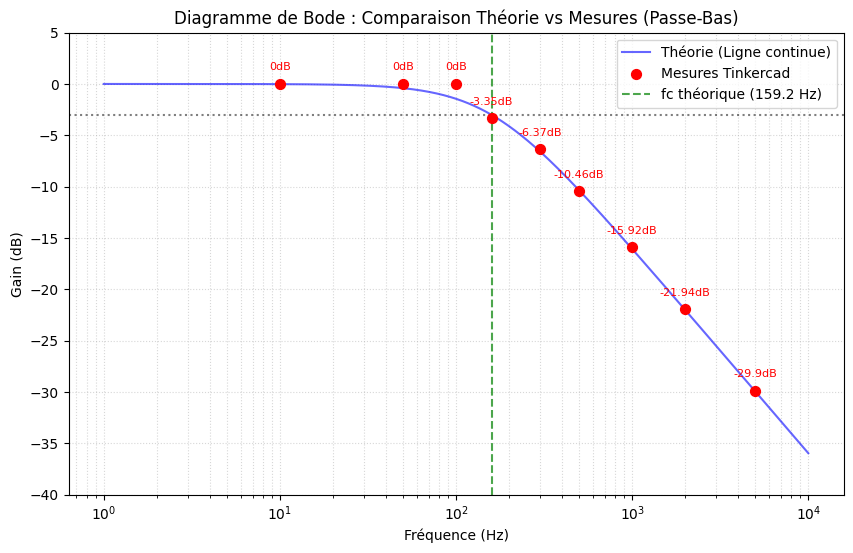

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

R = 1000
C = 1e-6
fc_theo = 159.15
f_model = np.logspace(0, 4, 1000)
gain_db_model = -10 * np.log10(1 + (f_model / fc_theo)**2)


f_mesure = [10, 50, 100, 159, 300, 500, 1000, 2000, 5000]

gdb_mesure = [0, 0, 0, -3.35, -6.37, -10.46, -15.92, -21.94, -29.90]

plt.figure(figsize=(10, 6))

plt.semilogx(f_model, gain_db_model, color='blue', label='Théorie (Ligne continue)', alpha=0.6)


plt.scatter(f_mesure, gdb_mesure, color='red', marker='o', s=50, label='Mesures Tinkercad', zorder=5)


for i, txt in enumerate(gdb_mesure):
    plt.annotate(f"{txt}dB", (f_mesure[i], gdb_mesure[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='red')


plt.axvline(fc_theo, color='green', linestyle='--', alpha=0.7, label=f'fc théorique ({fc_theo:.1f} Hz)')
plt.axhline(-3, color='black', linestyle=':', alpha=0.5)


plt.title("Diagramme de Bode : Comparaison Théorie vs Mesures (Passe-Bas)")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Gain (dB)")
plt.ylim(-40, 5)
plt.grid(True, which="both", linestyle=':', alpha=0.5)
plt.legend()

plt.show()

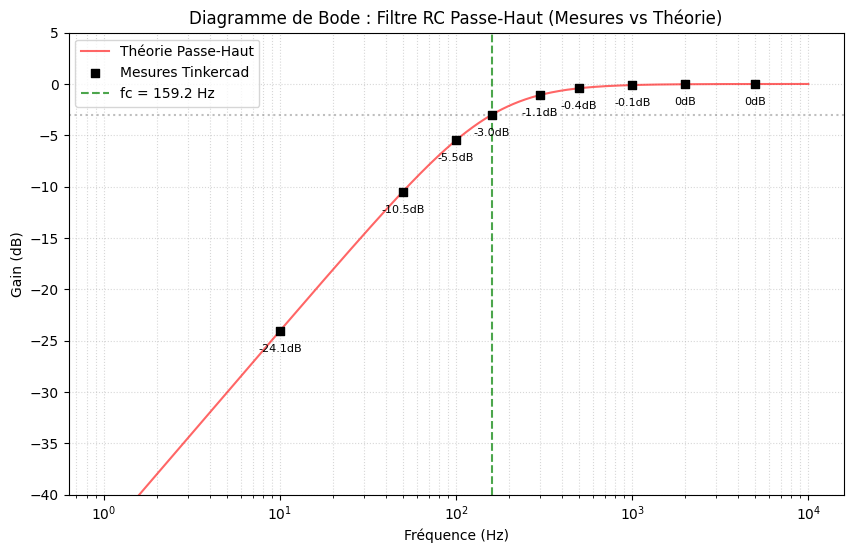

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

R = 1000
C = 1e-6
fc_theo = 159.15
f_model = np.logspace(0, 4, 1000)

gain_db_model = 20 * np.log10((f_model / fc_theo) / np.sqrt(1 + (f_model / fc_theo)**2))

f_mesure = [10, 50, 100, 159, 300, 500, 1000, 2000, 5000]

gdb_mesure = [-24.1, -10.5, -5.5, -3.0, -1.1, -0.4, -0.1, 0, 0]


plt.figure(figsize=(10, 6))


plt.semilogx(f_model, gain_db_model, color='red', label='Théorie Passe-Haut', alpha=0.6)


plt.scatter(f_mesure, gdb_mesure, color='black', marker='s', s=40, label='Mesures Tinkercad', zorder=5)


for i, txt in enumerate(gdb_mesure):
    plt.annotate(f"{txt}dB", (f_mesure[i], gdb_mesure[i]), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=8)

plt.axvline(fc_theo, color='green', linestyle='--', alpha=0.7, label=f'fc = {fc_theo:.1f} Hz')
plt.axhline(-3, color='gray', linestyle=':', alpha=0.5)


plt.title("Diagramme de Bode : Filtre RC Passe-Haut (Mesures vs Théorie)")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Gain (dB)")
plt.ylim(-40, 5)
plt.grid(True, which="both", linestyle=':', alpha=0.5)
plt.legend()

plt.show()